# mechanism_viewer examples

## Use correlation to profile the missing data

This notebook contains examples of how to use `missing_columns_correlation()` and `complete_and_missing_columns_correlation()` from `viewer_correlation.py`. Both functions use correlation to percieve the missingness pattern of each column. For example, if one square reveals an high correlation value, then its possible that pair of columns have some kind of relation that makes the missingness not random.

> Note: Correlation plots are exploratory. They should be used together with more checks before concluding the missing data mechanism of columns.

### 1. Generate synthetic datasets with missing values

In this notebook, one dataset will be used to demonstrate the functions inside `viewer_correlation.py`. This dataset contains a mixture of missing data mechanisms and missing rates.

In [ ]:
from mechanism_viewer import generate_dataset_with_missing_data, ColType

data = generate_dataset_with_missing_data(200, [ColType.DISCRETE, ColType.CONTINUOUS, ColType.CONTINUOUS,
                                           ColType.CONTINUOUS, ColType.CONTINUOUS], 1, ["MCAR", "MAR",
                                           "MCAR", "MNAR"], [0.2, 0.35, 0.4, 0.3])

display(data.head(10))

,Col1,Col2,Col3,Col4,Col5
0,5,-0.601969,2.569927,0.446640,NaN
1,4,0.760251,-1.107104,-0.213272,-1.441494
2,4,1.106329,1.388582,NaN,0.175546
3,5,0.771638,-2.659351,NaN,0.408512
4,5,-0.723339,-2.078377,-0.465450,-0.186372
5,3,2.433848,-1.240640,0.886517,-0.404666
6,5,-1.770243,-1.177528,NaN,-0.362957
7,4,-1.032629,0.203702,0.501033,0.174639
8,6,NaN,NaN,-1.042485,-1.809959
9,7,0.089394,NaN,NaN,NaN


### 2. Correlation between missing columns with `missing_columns_correlation()`

This function plots the correlation matrix for columns that contain missing values.
Essentially, values close to 1 suggest similar missingness behavior between two missing columns.

The function returns a `(figure, axis)` tuple, so that the user can adapt the plot to their wish. In addition, by setting `display_plot=True`, the function will also display the plot inside the notebook.

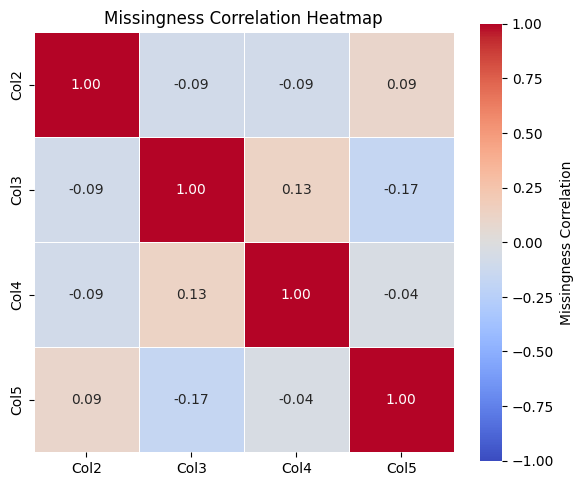

In [5]:
from mechanism_viewer import missing_columns_correlation

fig_miss_corr, ax_miss_corr = missing_columns_correlation(data, display_plot=True)

From the results, we can conclude that no particular missing column has missingness correlation with other missing columns. This means that each missing column has its values missings for different reasons/dependencies.

### 3. Correlation with complete + missing columns

`complete_and_missing_columns_correlation()` combines the complete columns (their original values) with the missingness of the missing columns. This helps to explore whether complete columns are associated with the missingness behavior in the missing columns.

The function also returns a `(figure, axis)` tuple, and has the option of setting `display_plot=True` to display the plot in the notebook.

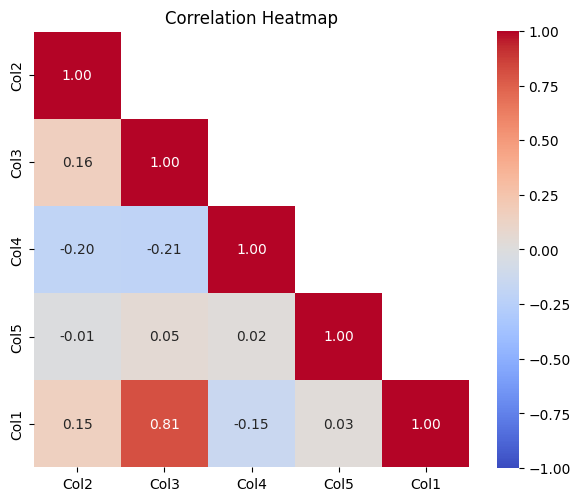

In [6]:
from mechanism_viewer import complete_and_missing_columns_correlation

fig_comp_corr, ax_comp_corr = complete_and_missing_columns_correlation(data, display_plot=True)